<a href="https://colab.research.google.com/github/baolong1507/Documentation/blob/main/SSM_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Libraries Installation**

In [2]:
!pip -q install --upgrade pip
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip -q install pytorch-lightning==2.4.0 opencv-python==4.10.0.84 \
                 einops==0.8.0 kornia==0.7.2 tqdm>=4.67 omegaconf==2.3.0 \
                 scikit-image==0.24.0 piq==0.8.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 25.3 MB/s eta 0:00:00


In [3]:
# !pip uninstall -y albumentations albucore opencv-python opencv-python-headless
!pip install -U "albumentations>=2.0.5" "albucore>=0.0.12" "opencv-python-headless>=4.8.0" "torch==2.8.0" torchvision

INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.


**Mount Drive**

In [22]:
import os
from google.colab import drive
drive.flush_and_unmount()

drive.mount('/content/drive')
PROJECT_ROOT = '/content/drive/MyDrive/derain_project'
os.makedirs(PROJECT_ROOT, exist_ok=True)

# Storage Folder in Drive
import os, time, getpass, socket
USER = getpass.getuser()
PROJECT = "derain_baseline"

BASE_DIR   = f"/content/drive/MyDrive/derain_project/{PROJECT}"
RUN_STAMP  = time.strftime("%Y%m%d-%H%M%S")
RUN_DIR    = os.path.join(BASE_DIR, RUN_STAMP)     # Folder for each time running
LOG_ROOT   = os.path.join(RUN_DIR, "logs")
CKPT_ROOT  = os.path.join(RUN_DIR, "checkpoints")

os.makedirs(LOG_ROOT, exist_ok=True)
os.makedirs(CKPT_ROOT, exist_ok=True)

print("LOG_ROOT :", LOG_ROOT)
print("CKPT_ROOT:", CKPT_ROOT)

Mounted at /content/drive
LOG_ROOT : /content/drive/MyDrive/derain_project/derain_baseline/20251028-043401/logs
CKPT_ROOT: /content/drive/MyDrive/derain_project/derain_baseline/20251028-043401/checkpoints


In [23]:
DATA_ROOT = f'{PROJECT_ROOT}/data'
CKPT_ROOT, LOG_ROOT, OUT_ROOT = f'{PROJECT_ROOT}/checkpoints', f'{PROJECT_ROOT}/logs', f'{PROJECT_ROOT}/outputs'
import os
for p in [CKPT_ROOT, LOG_ROOT, OUT_ROOT]: os.makedirs(p, exist_ok=True)


**Configuration**

In [24]:
from omegaconf import OmegaConf
cfg = OmegaConf.create({
    "img_size": 256,          # 256 hoặc 384 if GPU strong
    "crop_size": 256,
    "batch_size": 12,
    "num_workers": 2,
    "max_epochs": 13,         # fast baseline
    "lr": 2e-4,
    "weight_decay": 1e-5,
    # Choose DATASETS:
    "datasets": ["Rain200L","Rain200H","Rain1400","DID-Data"],
    "mix_datasets": True,     # False nếu muốn train/đánh giá riêng từng bộ
})
print(OmegaConf.to_yaml(cfg))

img_size: 256
crop_size: 256
batch_size: 12
num_workers: 2
max_epochs: 10
lr: 0.0002
weight_decay: 1.0e-05
datasets:
- Rain200L
- Rain200H
- Rain1400
- DID-Data
mix_datasets: true



**Dataloader**

In [25]:
import shutil, random, re
from pathlib import Path
from collections import defaultdict

def split_rain1400_train_val(
    root_dir,               # path tới thư mục Rain1400 (chứa train/ và test/)
    val_ratio=0.1,
    seed=42,
    move=False,             # True: move, False: copy
    CLEAN_NAME='clean',     # đổi thành 'norain' hoặc 'ground_truth' nếu cần
    DRY_RUN=False
):
    root = Path(root_dir)
    train_root = root / 'train'
    rainy_dir = train_root / 'input'
    clean_dir = train_root / 'target'
    assert rainy_dir.is_dir() and clean_dir.is_dir(), f"Thiếu {rainy_dir} hoặc {clean_dir}"

    exts = ('.png','.jpg','.jpeg','.bmp','.tif','.tiff')
    def list_images(d: Path):
        return [p for p in d.rglob('*') if p.suffix.lower() in exts]

    clean_files = list_images(clean_dir)
    rainy_files = list_images(rainy_dir)

    if not clean_files or not rainy_files:
        print(f"[Warn] clean={len(clean_files)}, rainy={len(rainy_files)} → Kiểm tra lại đường dẫn/đuôi ảnh.")
        return

    # --- Chuẩn hóa ID gốc ---
    # clean_id = stem của clean (vd 'xxx')
    # rainy_base_id = phần trước '-N' hoặc '_N' (vd 'xxx' từ 'xxx_12')
    # regex cắt suffix số ở cuối sau '-' hoặc '_'
    suffix_pat = re.compile(r'^(?P<base>.+?)(?:[-_](?P<idx>\d+))?$', re.IGNORECASE)

    def base_id_from_stem(stem: str) -> str:
        m = suffix_pat.match(stem)
        return m.group('base') if m else stem

    clean_ids = sorted({p.stem for p in clean_files})
    # map clean_id -> file sạch
    clean_map = {p.stem: p for p in clean_files}

    # nhóm rainy theo base_id
    rainy_group = defaultdict(list)
    for rf in rainy_files:
        base = base_id_from_stem(rf.stem)
        rainy_group[base].append(rf)

    # Một số bộ có clean khác extension → OK vì ta so theo stem
    # Lọc ra các base thực sự có cả clean
    bases_with_clean = sorted([cid for cid in clean_ids if cid in rainy_group])

    if not bases_with_clean:
        print("[Error] 0 base khớp giữa clean và rainy. Có thể tên clean không trùng base của rainy.")
        # gợi ý nhanh: in mẫu tên
        print("Ví dụ clean:", clean_files[0].name)
        print("Ví dụ rainy:", rainy_files[0].name)
        return

    # --- Chọn ID cho validation ---
    random.seed(seed)
    k = max(1, int(len(bases_with_clean)*val_ratio))
    val_ids = set(random.sample(bases_with_clean, k))
    train_ids = set(bases_with_clean) - val_ids

    # --- Thư mục đích ---
    val_clean = root/'val'/CLEAN_NAME
    val_rainy = root/'val'/'rainy'
    train_out_clean = root/'train_out'/CLEAN_NAME   # để không đè train gốc, bạn có thể đổi thành root/'train'
    train_out_rainy = root/'train_out'/'rainy'

    for d in (val_clean, val_rainy, train_out_clean, train_out_rainy):
        d.mkdir(parents=True, exist_ok=True)

    op = shutil.move if move else shutil.copy2

    moved_val = moved_train = 0

    # --- Copy/Move VAL ---
    for cid in val_ids:
        # clean
        cfile = clean_map.get(cid)
        if cfile:
            if not DRY_RUN:
                op(str(cfile), str(val_clean/cfile.name))
            moved_val += 1
        # all rainy variants
        for rf in rainy_group.get(cid, []):
            if not DRY_RUN:
                op(str(rf), str(val_rainy/rf.name))
            moved_val += 1

    # --- Copy/Move TRAIN (phần còn lại) ---
    for cid in train_ids:
        cfile = clean_map.get(cid)
        if cfile:
            if not DRY_RUN:
                op(str(cfile), str(train_out_clean/cfile.name))
            moved_train += 1
        for rf in rainy_group.get(cid, []):
            if not DRY_RUN:
                op(str(rf), str(train_out_rainy/rf.name))
            moved_train += 1

    # --- Thống kê ---
    total_rainy_val = len(list_images(val_rainy))
    total_clean_val = len(list_images(val_clean))
    total_rainy_train = len(list_images(train_out_rainy))
    total_clean_train = len(list_images(train_out_clean))

    print(f"[Rain1400] ID gốc tổng: {len(bases_with_clean)} | val_ids: {len(val_ids)} | train_ids: {len(train_ids)}")
    print(f"VAL: clean={total_clean_val}, rainy={total_rainy_val}")
    print(f"TRAIN: clean={total_clean_train}, rainy={total_rainy_train}")
    print(f"Files handled (incl. variants): moved_train={moved_train}, moved_val={moved_val}")
    if DRY_RUN:
        print("[DRY_RUN] Không copy/move file; bật move=True để di chuyển, hoặc để mặc định (copy).")

###################
# split_rain1400_train_val('/content/data/Rain1400', val_ratio=0.1, seed=42, move=False, CLEAN_NAME='clean', DRY_RUN=False)


In [26]:
import re

def canonical_stem(st: str):
    """
    Chuẩn hoá tên 'stem' để ghép cặp:
    - '1_1'..'1_14'  -> '1'    (Rain1400)
    - '001_rain'     -> '001'  (trường hợp khác)
    - giữ nguyên nếu không khớp các pattern trên
    """
    # 1) Rain1400: 'N_K' -> 'N'
    m = re.match(r'^(\d+)_\d{1,2}$', st)
    if m:
        return m.group(1)

    # 2) Bỏ hậu tố phổ biến _rain, _rainy, _clean
    st2 = re.sub(r'_(rain|rainy|clean)$', '', st, flags=re.IGNORECASE)

    return st2

In [27]:
# ---- CONFIG ----
import torch, cv2, os, random
import numpy as np
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path

cfg.auto_split_val = True      # tách 10% từ train làm val nếu thiếu thư mục val/
cfg.val_ratio = 0.10
cfg.split_seed = 42

# ---- Dataset class đã sửa để hỗ trợ Rain1400 (1 ảnh clean : 14 ảnh mưa) ----
import re
def canonical_stem(st: str):
    m = re.match(r'^(\d+)_\d{1,2}$', st)   # '1_1'..'1_14' -> '1'
    if m: return m.group(1)
    return re.sub(r'_(rain|rainy|clean)$', '', st, flags=re.IGNORECASE)

def build_transforms(img_size, crop_size, is_train):
    common = [
        A.LongestMaxSize(max_size=img_size),
        A.PadIfNeeded(img_size, img_size, border_mode=cv2.BORDER_REFLECT),
    ]
    if is_train:
        aug = common + [
            A.RandomCrop(crop_size, crop_size),
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(0.02, 0.1, 5, p=0.5, border_mode=cv2.BORDER_REFLECT),
        ]
    else:
        aug = common + [A.CenterCrop(crop_size, crop_size)]

    # LƯU Ý: không ColorJitter target (đang bỏ Jitter), Normalize + ToTensorV2 áp cho cả 2 ảnh
    aug += [A.Normalize((0.5,)*3, (0.5,)*3), ToTensorV2()]

    return A.Compose(
        aug,
        additional_targets={'target': 'image'}  # target xử lý như image
    )

class PairedDerainDataset(Dataset):
    def __init__(self, roots, split='train', transform=None, limit=None, shuffle=True):
        self.samples = []
        for r in roots:
            root = Path(r) / split
            if not root.exists():
                print(f"[WARN] Split '{split}' không tồn tại trong {r}, bỏ qua.")
                continue
            # duyệt cả dạng phẳng và đa thư mục con
            candidate_input_dirs = [d for d in root.glob('*/input') if d.is_dir()]
            if not candidate_input_dirs:
                candidate_input_dirs = [root / 'input']

            for rin in candidate_input_dirs:
                rgt = rin.parent / 'target'
                if not (rin.exists() and rgt.exists()):
                    continue
                gt_map = {canonical_stem(p.stem): str(p) for p in rgt.glob('*.*')}
                for ip in rin.glob('*.*'):
                    key = canonical_stem(ip.stem)
                    if key in gt_map:
                        self.samples.append((str(ip), gt_map[key], str(r)))
        if len(self.samples) == 0:
            print(f"[WARN] Không tìm thấy mẫu nào trong {roots} ({split}). Kiểm tra cấu trúc.")
        if shuffle: random.shuffle(self.samples)
        if limit:   self.samples = self.samples[:limit]
        self.t = transform

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        ip, gt, _ = self.samples[idx]
        im = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
        tg = cv2.cvtColor(cv2.imread(gt), cv2.COLOR_BGR2RGB)
        aug = self.t(image=im, target=tg)
        im, tg = aug['image'], aug['target']  # cả hai đều CHW
        return im, tg

# ---- Builders ----
from torch.utils.data import random_split, ConcatDataset

def check_has_val(root: Path):
    return (root / 'val' / 'input').exists() and (root / 'val' / 'target').exists()

def make_train_val_datasets(dataset_names):
    train_sets, val_sets = [], []
    g = torch.Generator().manual_seed(cfg.split_seed)
    for name in dataset_names:
        root = Path(DATA_ROOT) / name
        if check_has_val(root) and not cfg.auto_split_val:
            # dùng thư mục val có sẵn
            train_sets.append(PairedDerainDataset([str(root)], 'train', train_tf))
            val_sets.append(PairedDerainDataset([str(root)], 'val',   val_tf, shuffle=False))
            print(f"[{name}] Dùng val/ sẵn có.")
        else:
            # auto split từ train
            full = PairedDerainDataset([str(root)], 'train', train_tf, shuffle=True)
            n = len(full)
            if n == 0:
                print(f"[WARN] {name}: train rỗng → bỏ qua dataset này.")
                continue
            n_val = max(1, int(cfg.val_ratio * n))
            train_sub, val_sub = random_split(full, [n - n_val, n_val], generator=g)
            train_sets.append(train_sub)
            val_sets.append(val_sub)
            print(f"[{name}] Auto-split: val={n_val}/{n} ({cfg.val_ratio*100:.0f}%).")
    return ConcatDataset(train_sets), ConcatDataset(val_sets)

# ---- Build once, đừng ghi đè bên dưới nữa ----
train_tf = build_transforms(cfg.img_size, cfg.crop_size, True)
val_tf   = build_transforms(cfg.img_size, cfg.crop_size, False)

train_ds, val_ds = make_train_val_datasets(cfg.datasets)
train_dl = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,  num_workers=cfg.num_workers, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True)
print(f"Tổng train: {len(train_ds)} | Tổng val: {len(val_ds)}")


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


[Rain200L] Auto-split: val=180/1800 (10%).
[Rain200H] Auto-split: val=180/1800 (10%).
[Rain1400] Auto-split: val=1260/12600 (10%).
[DID-Data] Auto-split: val=1200/12000 (10%).
Tổng train: 25380 | Tổng val: 2820


In [28]:
ds_dbg = PairedDerainDataset([f"{DATA_ROOT}/Rain1400"], split='train', transform=val_tf, shuffle=False, limit=30)
print("Số cặp mẫu (train):", len(ds_dbg))
for i in range(3):
    print(ds_dbg.samples[i])  # in ra (đường dẫn rainy, đường dẫn clean, root)


Số cặp mẫu (train): 30
('/content/drive/MyDrive/derain_project/data/Rain1400/train/input/621_3.jpg', '/content/drive/MyDrive/derain_project/data/Rain1400/train/target/621.jpg', '/content/drive/MyDrive/derain_project/data/Rain1400')
('/content/drive/MyDrive/derain_project/data/Rain1400/train/input/622_3.jpg', '/content/drive/MyDrive/derain_project/data/Rain1400/train/target/622.jpg', '/content/drive/MyDrive/derain_project/data/Rain1400')
('/content/drive/MyDrive/derain_project/data/Rain1400/train/input/624_13.jpg', '/content/drive/MyDrive/derain_project/data/Rain1400/train/target/624.jpg', '/content/drive/MyDrive/derain_project/data/Rain1400')


Sanity-check for some samples

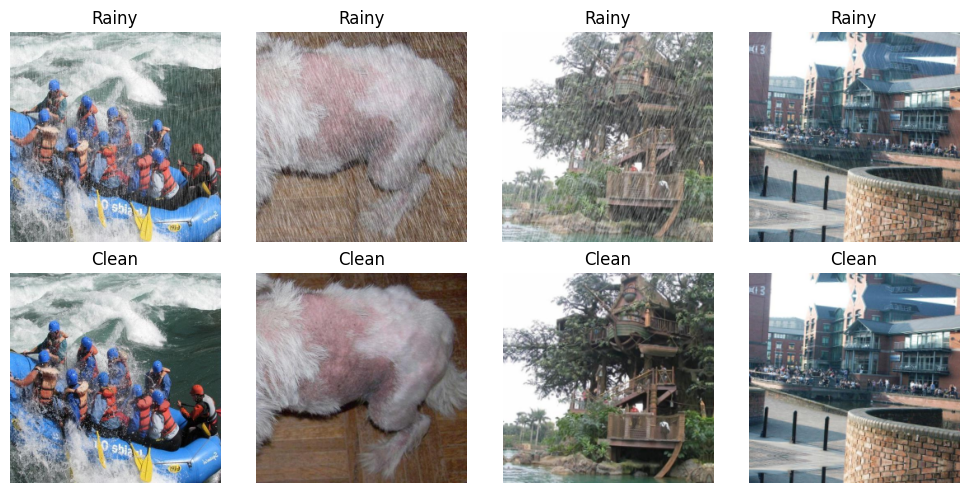

In [29]:
import matplotlib.pyplot as plt
import torch

def denorm(t):  #Normalize(mean=0.5,std=0.5)
    return (t*0.5 + 0.5).clamp(0,1)

def show_batch(xb, yb, k=4, title=("Rainy","Clean")):
    xb, yb = xb[:k], yb[:k]
    plt.figure(figsize=(10, 5))
    for i in range(len(xb)):
        plt.subplot(2, k, i+1)
        plt.imshow(denorm(xb[i]).permute(1,2,0).detach().cpu().numpy())
        plt.axis('off'); plt.title(title[0])

        plt.subplot(2, k, k+i+1)
        plt.imshow(denorm(yb[i]).permute(1,2,0).detach().cpu().numpy())
        plt.axis('off'); plt.title(title[1])
    plt.tight_layout(); plt.show()

xb, yb = next(iter(train_dl))
assert xb.ndim==4 and yb.ndim==4, (xb.shape, yb.shape)
assert xb.shape[1]==3 and yb.shape[1]==3, (xb.shape, yb.shape)  # (B,3,H,W)
show_batch(xb, yb, k=4)


**Model + Lightning (U-Net mini baseline)**

In [30]:
!pip install -q pytorch-lightning==2.4.0 piq==0.8.0

In [31]:
import torch.nn as nn, torch
import pytorch_lightning as pl
import torch.nn.functional as F
import piq

class DoubleConv(nn.Module):
    def __init__(self, c1, c2):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(c1,c2,3,padding=1), nn.ReLU(True),
                                 nn.Conv2d(c2,c2,3,padding=1), nn.ReLU(True))
    def forward(self,x): return self.net(x)

class UNetMini(nn.Module):
    def __init__(self, chs=(3,32,64,128,256)):
        super().__init__()
        c1,c2,c3,c4,c5 = chs
        self.d1=DoubleConv(c1,c2); self.p1=nn.MaxPool2d(2)
        self.d2=DoubleConv(c2,c3); self.p2=nn.MaxPool2d(2)
        self.d3=DoubleConv(c3,c4); self.p3=nn.MaxPool2d(2)
        self.b =DoubleConv(c4,c5)
        self.u3=nn.ConvTranspose2d(c5,c4,2,2); self.c3=DoubleConv(c5,c4)
        self.u2=nn.ConvTranspose2d(c4,c3,2,2); self.c2=DoubleConv(c4,c3)
        self.u1=nn.ConvTranspose2d(c3,c2,2,2); self.c1=DoubleConv(c3,c2)
        self.out=nn.Conv2d(c2,3,1)
    def forward(self,x):
        x1=self.d1(x); x2=self.d2(self.p1(x1)); x3=self.d3(self.p2(x2))
        xb=self.b(self.p3(x3))
        x=self.u3(xb); x=self.c3(torch.cat([x,x3],1))
        x=self.u2(x);  x=self.c2(torch.cat([x,x2],1))
        x=self.u1(x);  x=self.c1(torch.cat([x,x1],1))
        return torch.tanh(self.out(x))

class DerainLit(pl.LightningModule):
    def __init__(self, lr=2e-4, wd=1e-5):
        super().__init__()
        self.model = UNetMini()
        self.lr, self.wd = lr, wd

    def forward(self, x):
        return self.model(x)

    def _metrics(self, yhat, y):
        # chuyển từ [-1,1] -> [0,1]
        yhat01 = (yhat * 0.5 + 0.5).clamp(0,1)
        y01    = (y    * 0.5 + 0.5).clamp(0,1)
        psnr = piq.psnr(yhat01, y01, data_range=1.0)
        ssim = piq.ssim(yhat01,  y01, data_range=1.0)
        return psnr, ssim

    def training_step(self, batch, batch_idx):
        x, y = batch
        yhat = self(x)
        loss = F.l1_loss(yhat, y)
        psnr, ssim = self._metrics(yhat, y)
        self.log_dict({"train/l1": loss, "train/psnr": psnr, "train/ssim": ssim}, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        yhat = self(x)
        val_l1 = F.l1_loss(yhat, y)
        psnr, ssim = self._metrics(yhat, y)
        self.log_dict({"val/l1": val_l1, "val/psnr": psnr, "val/ssim": ssim}, prog_bar=True)

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=self.wd)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.trainer.max_epochs if self.trainer else 10)
        return {"optimizer": opt, "lr_scheduler": sch}



**Training**

In [35]:
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger
import pytorch_lightning as pl
import os

os.makedirs(LOG_ROOT, exist_ok=True)
os.makedirs(CKPT_ROOT, exist_ok=True)

logger = CSVLogger(save_dir=LOG_ROOT, name="derain_baseline")

# 1) Lưu MỌI epoch (không phụ thuộc metric)
ckpt_each_epoch = ModelCheckpoint(
    dirpath=CKPT_ROOT,
    filename="epoch-{epoch:03d}",   # file sẽ là epoch-001.ckpt, epoch-002.ckpt, ...
    save_top_k=-1,                  # -1 = save tất cả
    every_n_epochs=1,               # MỖI epoch
    save_last=True                  # thêm last.ckpt để resume nhanh
    # monitor=None  # không cần monitor
)

# 2) Lưu BEST theo metric (ví dụ val_l1)
ckpt_best = ModelCheckpoint(
    dirpath=CKPT_ROOT,
    filename="best-{epoch:03d}-{val_l1:.4f}",
    monitor="val/l1",               # nhớ log đúng tên này trong LightningModule
    mode="min",
    save_top_k=1
)

trainer = pl.Trainer(
    max_epochs=cfg.max_epochs,
    precision="16-mixed",
    logger=logger,
    callbacks=[ckpt_each_epoch, ckpt_best, LearningRateMonitor(logging_interval="step")],
    log_every_n_steps=50
)

trainer.fit(DerainLit(cfg.lr, cfg.weight_decay), train_dl, val_dl)
print("Best:", ckpt_best.best_model_path)


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | model | UNetMini | 1.9 M  | train
-------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.703     Total estimated model params size (MB)
50        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


Best: /content/drive/MyDrive/derain_project/checkpoints/best-epoch=009-val_l1=0.0000.ckpt


**Đánh giá riêng từng dataset trên test/ và lưu ảnh mẫu
Assessment of each dataset and save sample image**

In [39]:
# === 0) Chuẩn bị đường dẫn & chọn checkpoint an toàn ===
import os, glob, torch
from torch.utils.data import DataLoader
from torchvision.utils import save_image
import piq

# Sửa các biến đường dẫn theo notebook của bạn:
# CKPT_ROOT = "/content/checkpoints"   # thư mục bạn đã lưu ckpt lúc train (local hoặc Drive)
# DATA_ROOT = "/content/data"          # gốc dataset
OUT_ROOT  = "/content/drive/MyDrive/derain_project/outputs_eval"  # nơi lưu ảnh kết quả
os.makedirs(OUT_ROOT, exist_ok=True)

def pick_ckpt(ckpt_root):
    last = os.path.join(ckpt_root, "last.ckpt")
    if os.path.exists(last):
        return last
    ckpts = sorted(glob.glob(os.path.join(ckpt_root, "*.ckpt")), key=os.path.getmtime)
    assert ckpts, f"No .ckpt found in {ckpt_root}"
    return ckpts[-1]

ckpt_path = pick_ckpt(CKPT_ROOT)
print("→ Using checkpoint:", ckpt_path)

# === 1) Load model from checkpoint ===
# Lưu ý: tên tham số phải khớp với __init__ của DerainLit
# (trong lúc train bạn gọi DerainLit(cfg.lr, cfg.weight_decay) ⇒ dùng lr & weight_decay)
model = DerainLit.load_from_checkpoint(
    ckpt_path,
    lr=cfg.lr,
    weight_decay=cfg.weight_decay
).cuda().eval()

# === 2) Normalize ===
def denorm(t):  # từ [-1,1] → [0,1] để lưu ảnh
    return (t*0.5 + 0.5).clamp(0, 1)

# Nếu val_tf đã có sẵn trong notebook, dùng lại; nếu chưa có, thay bằng transform bạn đang dùng cho test
# val_tf = ...

# === 3) Function for assessing 1 dataset ===
@torch.inference_mode()
def eval_dataset(ds_name, save_samples=True):
    ds_path = f"{DATA_ROOT}/{ds_name}"
    assert os.path.exists(ds_path), f"Dataset not found: {ds_path}"

    ds = PairedDerainDataset([ds_path], split='test', transform=val_tf, shuffle=False)
    dl = DataLoader(ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

    out_dir = f"{OUT_ROOT}/{ds_name}"
    os.makedirs(out_dir, exist_ok=True)

    psnr_sum, ssim_sum, n = 0.0, 0.0, 0

    for i, (x, y) in enumerate(dl):
        x = x.cuda(non_blocking=True)
        y = y.cuda(non_blocking=True)

        # Dự đoán với autocast
        from torch import amp
        with amp.autocast('cuda'):
            yhat = model(x)

        # Revert to float32
        yhat = yhat.float()
        y = y.float()

        # 🔹 Denormalize về [0,1]
        yhat_dn, y_dn = denorm(yhat), denorm(y)
        # PIQ: dữ liệu của bạn ở [0,1] ⇒ data_range = 1.0
        yhat_dn = denorm(yhat)
        y_dn    = denorm(y)

        psnr_sum += piq.psnr(yhat_dn, y_dn, data_range=1.0).item()
        ssim_sum += piq.ssim(yhat_dn, y_dn, data_range=1.0).item()
        n += 1

        if save_samples:
            # ghép ảnh: Rainy | Cleaned | GT
            grid = torch.cat([denorm(x), denorm(yhat), denorm(y)], dim=0)  # (3,C,H,W) vì batch=1
            save_image(grid, f"{out_dir}/sample_{i:04d}.png", nrow=3)

    return psnr_sum / max(n, 1), ssim_sum / max(n, 1)

# === 4) Assessing on each dataset ===
datasets = ["Rain200L", "Rain200H", "Rain1400", "DID-Data"]
overall = []

for name in datasets:
    path = f"{DATA_ROOT}/{name}"
    if os.path.exists(path):
        p, s = eval_dataset(name)
        overall.append((name, p, s))
        print(f"{name}: PSNR={p:.3f}  SSIM={s:.4f}")
    else:
        print(f"Skip {name} (missing: {path})")

# (Optional) Average
if overall:
    import numpy as np
    mp = float(np.mean([p for _,p,_ in overall]))
    ms = float(np.mean([s for _,_,s in overall]))
    print(f"\nAverage over {len(overall)} sets → PSNR={mp:.3f}  SSIM={ms:.4f}")


→ Using checkpoint: /content/drive/MyDrive/derain_project/checkpoints/last.ckpt
Rain200L: PSNR=29.719  SSIM=0.9071
Rain200H: PSNR=23.188  SSIM=0.7352
Rain1400: PSNR=29.503  SSIM=0.8975
DID-Data: PSNR=30.798  SSIM=0.8916

Average over 4 sets → PSNR=28.302  SSIM=0.8578
